In [ ]:
pip install tensorflow

In [ ]:
pip install numpy Pillow scipy matplotlib

In [ ]:
pip install --upgrade pip 

In [ ]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Define dataset paths
datasetDir = "/Users/ashutosh/ProjectMajor/BASIC GEOMETRY"  # Update this path

# Image properties
imgSize = (128, 128)  # Resize images
batchSize = 32  # Batch size for training

# Data Augmentation
datagen = ImageDataGenerator(
    rescale=1.0/255,  # Normalize pixel values
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    validation_split=0.2  # 80-20 train-test split
)

# Load Training Data
trainData = datagen.flow_from_directory(
    datasetDir,
    target_size=imgSize,
    batch_size=batchSize,
    class_mode="categorical",
    subset="training"
)

# Load Validation Data
valData = datagen.flow_from_directory(
    datasetDir,
    target_size=imgSize,
    batch_size=batchSize,
    class_mode="categorical",
    subset="validation"
)

# Get class labels
classLabels = list(trainData.class_indices.keys())
print("Class Labels:", classLabels)


In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.applications import VGG19
from tensorflow.keras.optimizers import Adam

# Assume 'classLabels' is already defined from the data preprocessing step (Part 1)
num_classes = len(classLabels)

# Load VGG-19 pretrained on ImageNet without the top classification layer
baseModel = VGG19(weights="imagenet", include_top=False, input_shape=(128, 128, 3))

# Freeze the base model layers
for layer in baseModel.layers:
    layer.trainable = False

# Build the model
model = Sequential([
    baseModel,
    GlobalAveragePooling2D(),  # Alternatively, you can use Flatten() if desired.
    Dense(256, activation="relu"),
    Dropout(0.3),
    Dense(num_classes, activation="softmax")  # Final layer: one neuron per shape
])

# Compile the model
model.compile(optimizer=Adam(learning_rate=0.001),
              loss="categorical_crossentropy",
              metrics=["accuracy"])

# Train the model
epochs = 20
history = model.fit(
    trainData,         # From Part 1: training generator
    validation_data=valData,  # From Part 1: validation generator
    epochs=epochs
)

# Save the trained model
model.save("shape_classifier_vgg19.h5")
print("Model trained and saved as shape_classifier_vgg19.h5")

In [ ]:
import matplotlib.pyplot as plt

# Plot training & validation accuracy values
plt.figure(figsize=(8, 5))
plt.plot(history_vgg19.history['accuracy'], label='Train Accuracy')
plt.plot(history_vgg19.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.models import load_model

# Load the saved model
model = load_model("shape_classifier_vgg19.h5")

# Path to a test image
test_image_path = "/Users/ashutosh/ProjectMajor/BASIC GEOMETRY/RECTANGLE/plain_rect_Wo_5.png"  # Update with your test image path

# Load and preprocess the image
img = load_img(test_image_path, target_size=(128, 128))
img_array = img_to_array(img) / 255.0  # Normalize pixel values
img_array = np.expand_dims(img_array, axis=0)  # Add batch dimension

# Predict the class
prediction = model.predict(img_array)
predicted_index = np.argmax(prediction, axis=1)[0]
predicted_label = classLabels[predicted_index]

# Show the image with predicted label
plt.figure(figsize=(4,4))
plt.imshow(img)
plt.title(f"Predicted Shape: {predicted_label}")
plt.axis("off")
plt.show()


In [ ]:
from PIL import Image
i = Image.open(r"/Users/ashutosh/ProjectMajor/BasicGeometry_100x100_low/Square/plain_square_W/sq_sd_W_1_lowres.png")

'''i = Image.open(r"/Users/ashutosh/ProjectMajor/BasicGeometry_200x200_HIGHRES/Circle/Circle_Chord/circ_chr_0.png")
'''
w, h = i.size
print(w,h)


In [ ]:
# j=Image.open(r"/Users/ashutosh/ProjectMajor/BASIC GEOMETRY/PARALLELOGRAM/plain_para_W_5.png")
# k=Image.open(r"")

# width, height = j.size
# print(width,height)

In [ ]:
# pip install torch torchvision

In [ ]:
# import torch
# print(torch.backends.mps.is_available())  # Should print True
# print(torch.device("mps"))  # Should print 'mps'

MAKE THE CHANGES IN THE FILE OF THE BASIC GEOMETRY FOR THE 100*100

In [ ]:
# pip install tensorflow

In [11]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Define dataset paths
baseDir = r"/Users/ashutosh/ProjectMajor/GEOMETRICDATASET"
trainDir = os.path.join(baseDir, "train")
valDir = os.path.join(baseDir, "val")
testDir = os.path.join(baseDir, "test")

# Image properties
imgSize = (200, 200)
batchSize = 32

# Data augmentation for training
train_datagen = ImageDataGenerator(
    rescale=1.0/255,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True
)

# Only rescaling for validation and testing
val_datagen = ImageDataGenerator(rescale=1.0/255)
test_datagen = ImageDataGenerator(rescale=1.0/255)

# Load Training Data
trainData = train_datagen.flow_from_directory(
    trainDir,
    target_size=imgSize,
    batch_size=batchSize,
    class_mode="categorical"
)

# Load Validation Data
valData = val_datagen.flow_from_directory(
    valDir,
    target_size=imgSize,
    batch_size=batchSize,
    class_mode="categorical"
)

# (Optional) Load Test Data
testData = test_datagen.flow_from_directory(
    testDir,
    target_size=imgSize,
    batch_size=batchSize,
    class_mode="categorical",
    shuffle=False  # Important for evaluation
)

# Get class labels
classLabels = list(trainData.class_indices.keys())
print("Class Labels:", classLabels)






Found 307800 images belonging to 76 classes.
Found 34200 images belonging to 76 classes.
Found 38000 images belonging to 76 classes.
Class Labels: ['Circle_Circle_Chord', 'Circle_Circle_Diameter', 'Circle_Circle_Radius', 'Circle_Plain', 'Inscribed_Circle_Square', 'Inscribed_Circle_Square_diagonals', 'Inscribed_Circle_Square_two_diagonals', 'Inscribed_Circle_right_angle_triangle', 'Inscribed_Circle_triangle', 'Inscribed_Square_Circle', 'Parallelogram_para_diag_perp_W', 'Parallelogram_para_diag_perp_Wo', 'Parallelogram_para_double_diagonal_W', 'Parallelogram_para_double_diagonal_Wo', 'Parallelogram_para_perp_W', 'Parallelogram_para_perp_Wo', 'Parallelogram_para_single_diagonal_W', 'Parallelogram_para_single_diagonal_Wo', 'Parallelogram_plain_para__W', 'Parallelogram_plain_para__Wo', 'Rectangle_plain_rect_W', 'Rectangle_plain_rect_Wo', 'Rectangle_rectangle_one_angle_one_diagonal_W', 'Rectangle_rectangle_one_angle_one_diagonal_Wo', 'Rectangle_rectangle_two_angles_one_diagonal_W', 'Rectangl

### VGG-16 Model 

In [ ]:
# Number of classes
num_classes = len(classLabels)
epochs=10

In [ ]:
# #VGG MODEL 


# from tensorflow.keras.applications import VGG16
# from tensorflow.keras.models import Sequential
# from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
# from tensorflow.keras.optimizers import Adam



# # Load VGG-16 pretrained on ImageNet without the top classification layer
# baseModel = VGG16(weights="imagenet", include_top=False, input_shape=(200, 200, 3))

# # Freeze the base model layers
# for layer in baseModel.layers:
#     layer.trainable = False

# # Build the model
# model_vgg16 = Sequential([
#     baseModel,
#     GlobalAveragePooling2D(),
#     Dense(256, activation="relu"),
#     Dropout(0.3),
#     Dense(num_classes, activation="softmax")
# ])

# # Compile the model
# model_vgg16.compile(optimizer=Adam(learning_rate=0.001),
#                     loss="categorical_crossentropy",
#                     metrics=["accuracy"])

# # Train the model
# history_vgg16 = model_vgg16.fit(
#     trainData,
#     validation_data=valData,
#     epochs=epochs
# )

# # Save the trained model
# model_vgg16.save("shape_classifier_vgg16.h5")
# print("VGG16 model trained and saved as shape_classifier_vgg16.h5")


VGG 16

Available physical devices: []
Found 307800 images belonging to 76 classes.
Found 34200 images belonging to 76 classes.
Class Labels: ['Circle_Circle_Chord', 'Circle_Circle_Diameter', 'Circle_Circle_Radius', 'Circle_Plain', 'Inscribed_Circle_Square', 'Inscribed_Circle_Square_diagonals', 'Inscribed_Circle_Square_two_diagonals', 'Inscribed_Circle_right_angle_triangle', 'Inscribed_Circle_triangle', 'Inscribed_Square_Circle', 'Parallelogram_para_diag_perp_W', 'Parallelogram_para_diag_perp_Wo', 'Parallelogram_para_double_diagonal_W', 'Parallelogram_para_double_diagonal_Wo', 'Parallelogram_para_perp_W', 'Parallelogram_para_perp_Wo', 'Parallelogram_para_single_diagonal_W', 'Parallelogram_para_single_diagonal_Wo', 'Parallelogram_plain_para__W', 'Parallelogram_plain_para__Wo', 'Rectangle_plain_rect_W', 'Rectangle_plain_rect_Wo', 'Rectangle_rectangle_one_angle_one_diagonal_W', 'Rectangle_rectangle_one_angle_one_diagonal_Wo', 'Rectangle_rectangle_two_angles_one_diagonal_W', 'Rectangle_rectangle_t

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/3
4810/4810 ━━━━━━━━━━━━━━━━━━━━ 10988s 2s/step - accuracy: 0.4821 - loss: 1.6822 - val_accuracy: 0.7590 - val_loss: 0.5417
Epoch 2/3
4810/4810 ━━━━━━━━━━━━━━━━━━━━ 10944s 2s/step - accuracy: 0.7410 - loss: 0.5758 - val_accuracy: 0.7911 - val_loss: 0.4385
Epoch 3/3
4810/4810 ━━━━━━━━━━━━━━━━━━━━ 10760s 2s/step - accuracy: 0.7731 - loss: 0.4826 - val_accuracy: 0.8133 - val_loss: 0.3903


✅ VGG16 model trained and saved as shape_classifier_vgg16_fast.h5


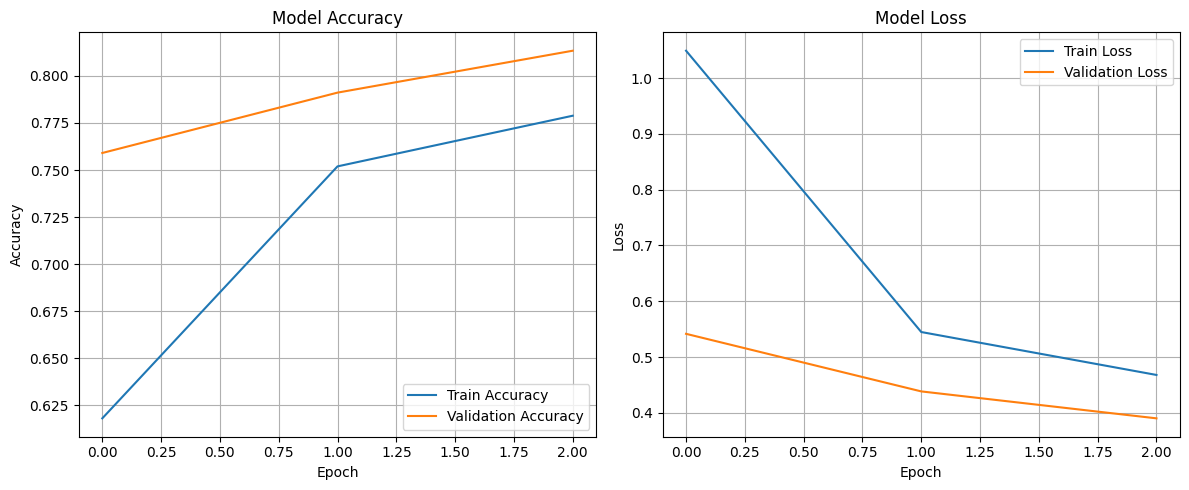

In [13]:
import os
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras import mixed_precision

# ✅ Enable Apple MPS GPU acceleration if available
physical_devices = tf.config.list_physical_devices('GPU')
print("Available physical devices:", physical_devices)

if physical_devices:
    try:
        tf.config.experimental.set_memory_growth(physical_devices[0], True)
    except:
        pass

# ✅ Enable mixed precision for speed boost
mixed_precision.set_global_policy("mixed_float16")

# ✅ Define dataset paths
baseDir = r"/Users/ashutosh/ProjectMajor/GEOMETRICDATASET"
trainDir = os.path.join(baseDir, "train")
valDir = os.path.join(baseDir, "val")
testDir = os.path.join(baseDir, "test")

# ✅ Image properties
imgSize = (128, 128)
batchSize = 64

# ✅ Only rescaling, no augmentation
data_gen = ImageDataGenerator(rescale=1.0/255)

# ✅ Load Training Data
trainData = data_gen.flow_from_directory(
    trainDir,
    target_size=imgSize,
    batch_size=batchSize,
    class_mode="categorical"
)

# ✅ Load Validation Data
valData = data_gen.flow_from_directory(
    valDir,
    target_size=imgSize,
    batch_size=batchSize,
    class_mode="categorical"
)

# ✅ Get class labels
classLabels = list(trainData.class_indices.keys())
num_classes = len(classLabels)
print("Class Labels:", classLabels)

# ✅ Load VGG-16 pretrained on ImageNet without the top classification layer
baseModel = VGG16(weights="imagenet", include_top=False, input_shape=(128, 128, 3))

# ✅ Freeze base model layers
for layer in baseModel.layers:
    layer.trainable = False

# ✅ Build the model
model_vgg16 = Sequential([
    baseModel,
    GlobalAveragePooling2D(),
    Dense(256, activation="relu"),
    Dropout(0.3),
    Dense(num_classes, activation="softmax")
])

# ✅ Compile the model
model_vgg16.compile(optimizer=Adam(learning_rate=0.001),
                    loss="categorical_crossentropy",
                    metrics=["accuracy"])

# ✅ Train the model
epochs = 3
history_vgg16 = model_vgg16.fit(
    trainData,
    validation_data=valData,
    epochs=epochs
)

# ✅ Save the trained model
model_vgg16.save("shape_classifier_vgg16_fast.h5")
print("✅ VGG16 model trained and saved as shape_classifier_vgg16_fast.h5")


plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history_vgg16.history['accuracy'], label='Train Accuracy')
plt.plot(history_vgg16.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.grid(True)

# ✅ Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history_vgg16.history['loss'], label='Train Loss')
plt.plot(history_vgg16.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.grid(True)

plt.tight_layout()
plt.show()

RESNET 

Available physical devices: []
Found 307800 images belonging to 76 classes.
Found 34200 images belonging to 76 classes.
Class Labels: ['Circle_Circle_Chord', 'Circle_Circle_Diameter', 'Circle_Circle_Radius', 'Circle_Plain', 'Inscribed_Circle_Square', 'Inscribed_Circle_Square_diagonals', 'Inscribed_Circle_Square_two_diagonals', 'Inscribed_Circle_right_angle_triangle', 'Inscribed_Circle_triangle', 'Inscribed_Square_Circle', 'Parallelogram_para_diag_perp_W', 'Parallelogram_para_diag_perp_Wo', 'Parallelogram_para_double_diagonal_W', 'Parallelogram_para_double_diagonal_Wo', 'Parallelogram_para_perp_W', 'Parallelogram_para_perp_Wo', 'Parallelogram_para_single_diagonal_W', 'Parallelogram_para_single_diagonal_Wo', 'Parallelogram_plain_para__W', 'Parallelogram_plain_para__Wo', 'Rectangle_plain_rect_W', 'Rectangle_plain_rect_Wo', 'Rectangle_rectangle_one_angle_one_diagonal_W', 'Rectangle_rectangle_one_angle_one_diagonal_Wo', 'Rectangle_rectangle_two_angles_one_diagonal_W', 'Rectangle_rectangle_t

✅ ResNet50 model trained and saved as shape_classifier_resnet50.h5


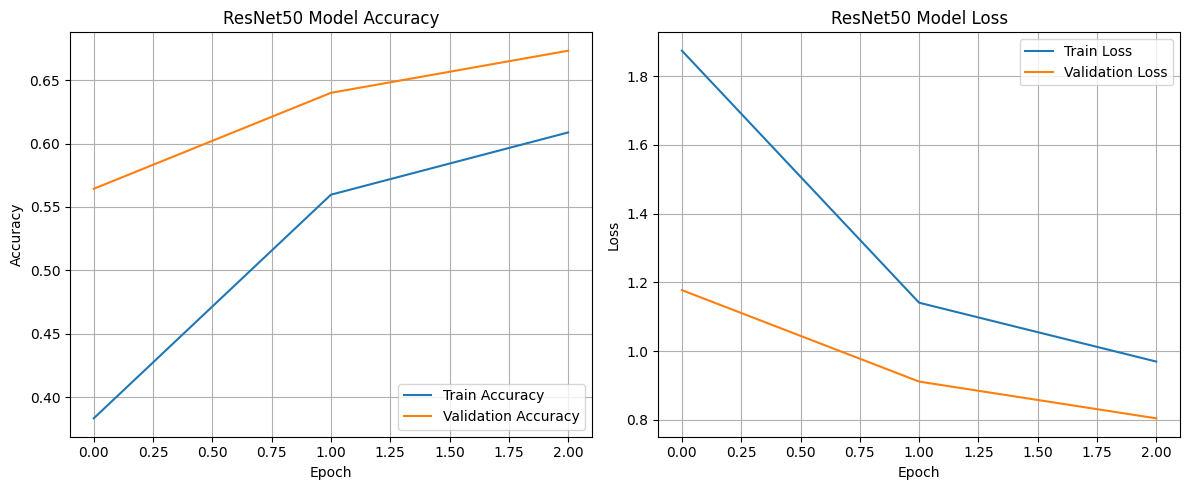

In [14]:
import os
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras import mixed_precision

# ✅ Enable Apple MPS GPU acceleration if available
physical_devices = tf.config.list_physical_devices('GPU')
print("Available physical devices:", physical_devices)

if physical_devices:
    try:
        tf.config.experimental.set_memory_growth(physical_devices[0], True)
    except:
        pass

# ✅ Enable mixed precision for speed boost
mixed_precision.set_global_policy("mixed_float16")

# ✅ Define dataset paths
baseDir = r"/Users/ashutosh/ProjectMajor/GEOMETRICDATASET"
trainDir = os.path.join(baseDir, "train")
valDir = os.path.join(baseDir, "val")

# ✅ Image properties
imgSize = (128, 128)
batchSize = 64

# ✅ Only rescaling, no augmentation
data_gen = ImageDataGenerator(rescale=1.0/255)

# ✅ Load Training Data
trainData = data_gen.flow_from_directory(
    trainDir,
    target_size=imgSize,
    batch_size=batchSize,
    class_mode="categorical"
)

# ✅ Load Validation Data
valData = data_gen.flow_from_directory(
    valDir,
    target_size=imgSize,
    batch_size=batchSize,
    class_mode="categorical"
)

# ✅ Get class labels
classLabels = list(trainData.class_indices.keys())
num_classes = len(classLabels)
print("Class Labels:", classLabels)

# ✅ Load ResNet50 pretrained on ImageNet without the top classification layer
baseModel = ResNet50(weights="imagenet", include_top=False, input_shape=(128, 128, 3))

# ✅ Freeze base model layers
for layer in baseModel.layers:
    layer.trainable = False

# ✅ Build the model
model_resnet = Sequential([
    baseModel,
    GlobalAveragePooling2D(),
    Dense(256, activation="relu"),
    Dropout(0.3),
    Dense(num_classes, activation="softmax")
])

# ✅ Compile the model
model_resnet.compile(optimizer=Adam(learning_rate=0.001),
                     loss="categorical_crossentropy",
                     metrics=["accuracy"])

# ✅ Train the model
epochs = 3
history_resnet = model_resnet.fit(
    trainData,
    validation_data=valData,
    epochs=epochs
)

# ✅ Save the trained model
model_resnet.save("shape_classifier_resnet50.h5")
print("✅ ResNet50 model trained and saved as shape_classifier_resnet50.h5")

# ✅ Plot training & validation accuracy and loss
plt.figure(figsize=(12, 5))

# Accuracy plot
plt.subplot(1, 2, 1)
plt.plot(history_resnet.history['accuracy'], label='Train Accuracy')
plt.plot(history_resnet.history['val_accuracy'], label='Validation Accuracy')
plt.title('ResNet50 Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.grid(True)

# Loss plot
plt.subplot(1, 2, 2)
plt.plot(history_resnet.history['loss'], label='Train Loss')
plt.plot(history_resnet.history['val_loss'], label='Validation Loss')
plt.title('ResNet50 Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.grid(True)

plt.tight_layout()
plt.show()


DENSENET 121

Available physical devices: []
Found 307800 images belonging to 76 classes.
Found 34200 images belonging to 76 classes.
Class Labels: ['Circle_Circle_Chord', 'Circle_Circle_Diameter', 'Circle_Circle_Radius', 'Circle_Plain', 'Inscribed_Circle_Square', 'Inscribed_Circle_Square_diagonals', 'Inscribed_Circle_Square_two_diagonals', 'Inscribed_Circle_right_angle_triangle', 'Inscribed_Circle_triangle', 'Inscribed_Square_Circle', 'Parallelogram_para_diag_perp_W', 'Parallelogram_para_diag_perp_Wo', 'Parallelogram_para_double_diagonal_W', 'Parallelogram_para_double_diagonal_Wo', 'Parallelogram_para_perp_W', 'Parallelogram_para_perp_Wo', 'Parallelogram_para_single_diagonal_W', 'Parallelogram_para_single_diagonal_Wo', 'Parallelogram_plain_para__W', 'Parallelogram_plain_para__Wo', 'Rectangle_plain_rect_W', 'Rectangle_plain_rect_Wo', 'Rectangle_rectangle_one_angle_one_diagonal_W', 'Rectangle_rectangle_one_angle_one_diagonal_Wo', 'Rectangle_rectangle_two_angles_one_diagonal_W', 'Rectangle_rectangle_t

✅ DenseNet121 model trained and saved as shape_classifier_densenet121.h5


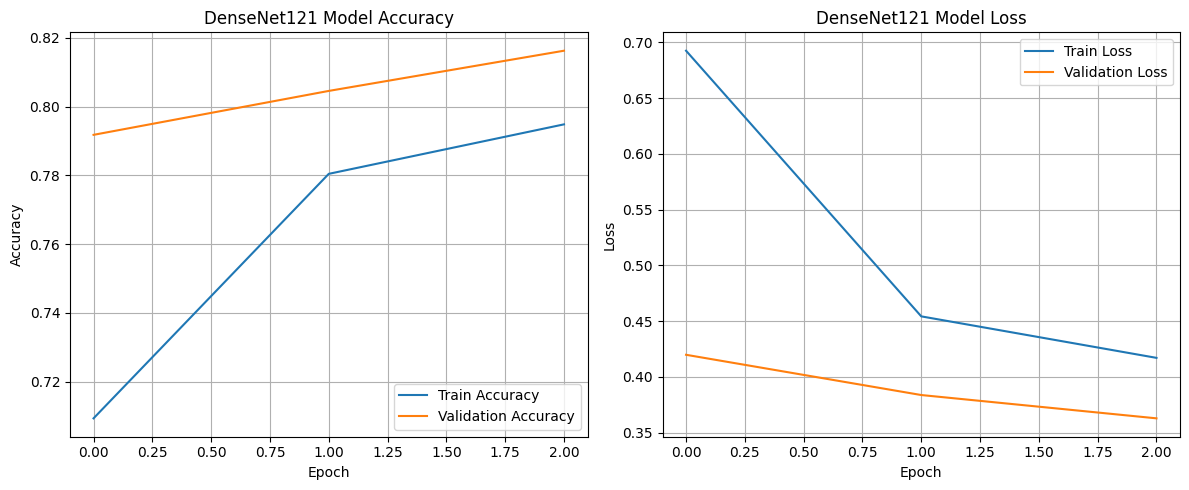

In [15]:
import os
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras import mixed_precision
import matplotlib.pyplot as plt

# ✅ MPS & Mixed Precision
physical_devices = tf.config.list_physical_devices('GPU')
print("Available physical devices:", physical_devices)
if physical_devices:
    try:
        tf.config.experimental.set_memory_growth(physical_devices[0], True)
    except:
        pass
mixed_precision.set_global_policy("mixed_float16")

# ✅ Dataset paths
baseDir = r"/Users/ashutosh/ProjectMajor/GEOMETRICDATASET"
trainDir = os.path.join(baseDir, "train")
valDir = os.path.join(baseDir, "val")

# ✅ Image settings
imgSize = (128, 128)
batchSize = 64

# ✅ Data generator (rescaling only)
data_gen = ImageDataGenerator(rescale=1.0/255)
trainData = data_gen.flow_from_directory(trainDir, target_size=imgSize, batch_size=batchSize, class_mode="categorical")
valData = data_gen.flow_from_directory(valDir, target_size=imgSize, batch_size=batchSize, class_mode="categorical")

# ✅ Class labels
classLabels = list(trainData.class_indices.keys())
num_classes = len(classLabels)
print("Class Labels:", classLabels)

# ✅ DenseNet121 base model
baseModel = DenseNet121(weights="imagenet", include_top=False, input_shape=(128, 128, 3))
for layer in baseModel.layers:
    layer.trainable = False

# ✅ Model definition
model_densenet = Sequential([
    baseModel,
    GlobalAveragePooling2D(),
    Dense(256, activation="relu"),
    Dropout(0.3),
    Dense(num_classes, activation="softmax")
])

# ✅ Compile
model_densenet.compile(optimizer=Adam(learning_rate=0.001),
                       loss="categorical_crossentropy",
                       metrics=["accuracy"])

# ✅ Train and capture history
epochs = 3
history_densenet = model_densenet.fit(trainData, validation_data=valData, epochs=epochs)

# ✅ Save model
model_densenet.save("shape_classifier_densenet121.h5")
print("✅ DenseNet121 model trained and saved as shape_classifier_densenet121.h5")

# ✅ Plot training & validation accuracy and loss
plt.figure(figsize=(12, 5))

# Accuracy plot
plt.subplot(1, 2, 1)
plt.plot(history_densenet.history['accuracy'], label='Train Accuracy')
plt.plot(history_densenet.history['val_accuracy'], label='Validation Accuracy')
plt.title('DenseNet121 Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.grid(True)

# Loss plot
plt.subplot(1, 2, 2)
plt.plot(history_densenet.history['loss'], label='Train Loss')
plt.plot(history_densenet.history['val_loss'], label='Validation Loss')
plt.title('DenseNet121 Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.grid(True)

plt.tight_layout()
plt.show()


MOBILENETv2

Epoch 1/3
4810/4810 ━━━━━━━━━━━━━━━━━━━━ 1076s 223ms/step - accuracy: 0.6725 - loss: 0.8965 - val_accuracy: 0.8173 - val_loss: 0.3562
Epoch 2/3
4810/4810 ━━━━━━━━━━━━━━━━━━━━ 1106s 230ms/step - accuracy: 0.8097 - loss: 0.3896 - val_accuracy: 0.8366 - val_loss: 0.3223
Epoch 3/3
4810/4810 ━━━━━━━━━━━━━━━━━━━━ 1113s 231ms/step - accuracy: 0.8226 - loss: 0.3597 - val_accuracy: 0.8406 - val_loss: 0.3097


✅ MobileNetV2 model trained and saved as shape_classifier_mobilenetv2.h5


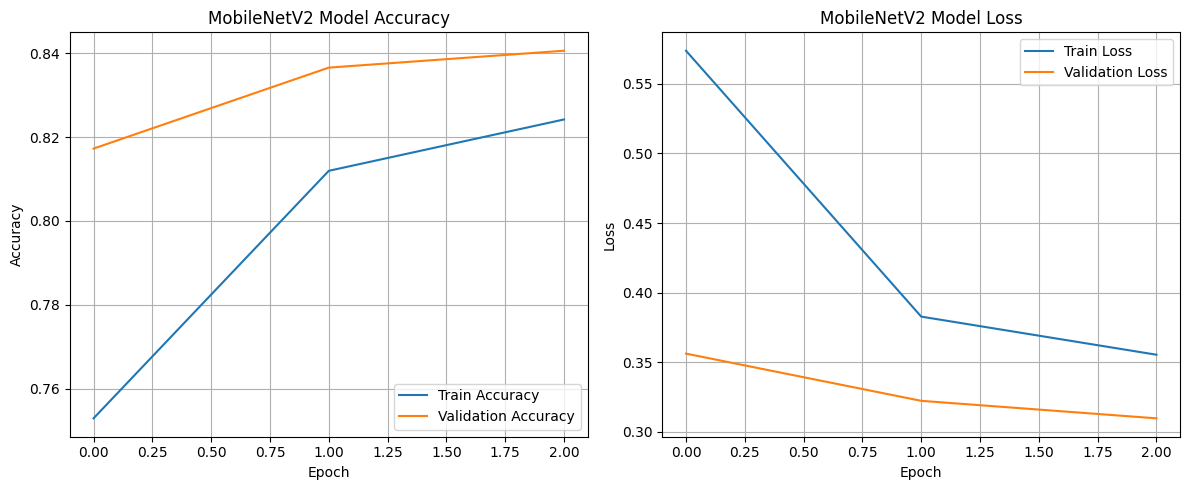

In [16]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt

# ✅ MobileNetV2 base model
baseModel = MobileNetV2(weights="imagenet", include_top=False, input_shape=(128, 128, 3))
for layer in baseModel.layers:
    layer.trainable = False

# ✅ Model definition
model_mobilenet = Sequential([
    baseModel,
    GlobalAveragePooling2D(),
    Dense(256, activation="relu"),
    Dropout(0.3),
    Dense(num_classes, activation="softmax")
])

# ✅ Compile
model_mobilenet.compile(optimizer=Adam(learning_rate=0.001),
                        loss="categorical_crossentropy",
                        metrics=["accuracy"])

# ✅ Train and capture history
epochs = 3
history_mobilenet = model_mobilenet.fit(trainData, validation_data=valData, epochs=epochs)

# ✅ Save
model_mobilenet.save("shape_classifier_mobilenetv2.h5")
print("✅ MobileNetV2 model trained and saved as shape_classifier_mobilenetv2.h5")

# ✅ Plot training & validation accuracy and loss
plt.figure(figsize=(12, 5))

# Accuracy plot
plt.subplot(1, 2, 1)
plt.plot(history_mobilenet.history['accuracy'], label='Train Accuracy')
plt.plot(history_mobilenet.history['val_accuracy'], label='Validation Accuracy')
plt.title('MobileNetV2 Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.grid(True)

# Loss plot
plt.subplot(1, 2, 2)
plt.plot(history_mobilenet.history['loss'], label='Train Loss')
plt.plot(history_mobilenet.history['val_loss'], label='Validation Loss')
plt.title('MobileNetV2 Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.grid(True)

plt.tight_layout()
plt.show()


VGG-19

Epoch 1/3
4810/4810 ━━━━━━━━━━━━━━━━━━━━ 13715s 3s/step - accuracy: 0.4684 - loss: 1.7565 - val_accuracy: 0.7567 - val_loss: 0.5669
Epoch 2/3
4810/4810 ━━━━━━━━━━━━━━━━━━━━ 13565s 3s/step - accuracy: 0.7399 - loss: 0.5968 - val_accuracy: 0.7920 - val_loss: 0.4525
Epoch 3/3
4810/4810 ━━━━━━━━━━━━━━━━━━━━ 13516s 3s/step - accuracy: 0.7710 - loss: 0.4983 - val_accuracy: 0.8120 - val_loss: 0.3978


✅ VGG19 model trained and saved as shape_classifier_vgg19.h5


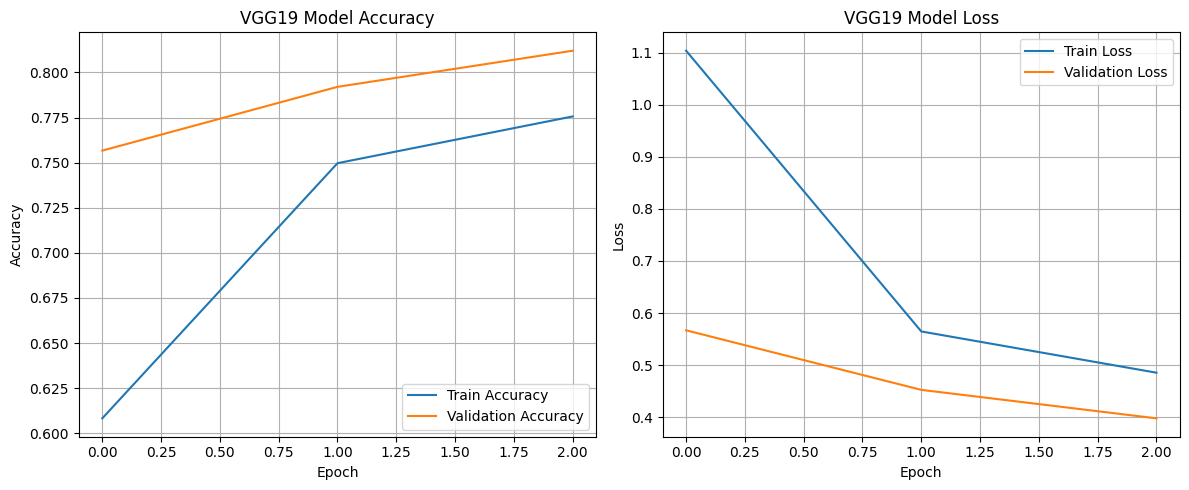

In [17]:
from tensorflow.keras.applications import VGG19
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt

# ✅ Load VGG-19 pretrained on ImageNet without top layer
baseModel = VGG19(weights="imagenet", include_top=False, input_shape=(128, 128, 3))

# ✅ Freeze the base model layers
for layer in baseModel.layers:
    layer.trainable = False

# ✅ Define the model
model_vgg19 = Sequential([
    baseModel,
    GlobalAveragePooling2D(),
    Dense(256, activation="relu"),
    Dropout(0.3),
    Dense(num_classes, activation="softmax")
])

# ✅ Compile the model
model_vgg19.compile(optimizer=Adam(learning_rate=0.001),
                    loss="categorical_crossentropy",
                    metrics=["accuracy"])

# ✅ Train the model and capture history
epochs = 3
history_vgg19 = model_vgg19.fit(trainData, validation_data=valData, epochs=epochs)

# ✅ Save the trained model
model_vgg19.save("shape_classifier_vgg19.h5")
print("✅ VGG19 model trained and saved as shape_classifier_vgg19.h5")

# ✅ Plot training & validation accuracy and loss
plt.figure(figsize=(12, 5))

# Accuracy plot
plt.subplot(1, 2, 1)
plt.plot(history_vgg19.history['accuracy'], label='Train Accuracy')
plt.plot(history_vgg19.history['val_accuracy'], label='Validation Accuracy')
plt.title('VGG19 Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.grid(True)

# Loss plot
plt.subplot(1, 2, 2)
plt.plot(history_vgg19.history['loss'], label='Train Loss')
plt.plot(history_vgg19.history['val_loss'], label='Validation Loss')
plt.title('VGG19 Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.grid(True)

plt.tight_layout()
plt.show()


In [26]:
pip install tqdm

  Using cached tqdm-4.67.1-py3-none-any.whl.metadata (57 kB)
Using cached tqdm-4.67.1-py3-none-any.whl (78 kB)
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 24.2 -> 25.0.1
[notice] To update, run: python3 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [28]:
import os
import shutil
import random
from tqdm import tqdm

# ✅ Original dataset directory
source_dir = r"/Users/ashutosh/ProjectMajor/BasicGeometry_200x200_HIGHRES"

# ✅ New split directories
base_dest = r"/Users/ashutosh/ProjectMajor/TESTTRAINVALSPLIT"
train_dir = os.path.join(base_dest, "train")
val_dir   = os.path.join(base_dest, "val")
test_dir  = os.path.join(base_dest, "test")

# ✅ Function to create dirs if not exist
def make_dirs(path):
    if not os.path.exists(path):
        os.makedirs(path)

# ✅ Function to split images into train, val, test
def split_dataset(source_folder, train_folder, val_folder, test_folder, split_ratio=(0.8, 0.1, 0.1)):
    for shape_class in os.listdir(source_folder):
        class_path = os.path.join(source_folder, shape_class)
        if os.path.isdir(class_path):
            for subfolder in os.listdir(class_path):
                subfolder_path = os.path.join(class_path, subfolder)
                if os.path.isdir(subfolder_path):
                    images = os.listdir(subfolder_path)
                    random.shuffle(images)

                    n_total = len(images)
                    n_train = int(n_total * split_ratio[0])
                    n_val   = int(n_total * split_ratio[1])

                    train_imgs = images[:n_train]
                    val_imgs   = images[n_train:n_train + n_val]
                    test_imgs  = images[n_train + n_val:]

                    # Create corresponding destination folders
                    dest_train = os.path.join(train_folder, shape_class, subfolder)
                    dest_val   = os.path.join(val_folder, shape_class, subfolder)
                    dest_test  = os.path.join(test_folder, shape_class, subfolder)
                    make_dirs(dest_train)
                    make_dirs(dest_val)
                    make_dirs(dest_test)

                    # Copy images
                    for img in tqdm(train_imgs, desc=f"Train {shape_class}/{subfolder}"):
                        shutil.copy(os.path.join(subfolder_path, img), os.path.join(dest_train, img))
                    for img in tqdm(val_imgs, desc=f"Val {shape_class}/{subfolder}"):
                        shutil.copy(os.path.join(subfolder_path, img), os.path.join(dest_val, img))
                    for img in tqdm(test_imgs, desc=f"Test {shape_class}/{subfolder}"):
                        shutil.copy(os.path.join(subfolder_path, img), os.path.join(dest_test, img))

# ✅ Run the split
split_dataset(source_dir, train_dir, val_dir, test_dir)

print("✅ Dataset split successfully into train, val, and test folders.")


Test Square/square_with_both_diagonals_Wo: 100%|██████████| 500/500 [00:00<00:00, 3321.57it/s]
Train Square/square_all_angles_and_single_diagonal_Wo: 100%|██████████| 4000/4000 [00:01<00:00, 2648.82it/s]
Val Square/square_all_angles_and_single_diagonal_Wo: 100%|██████████| 500/500 [00:00<00:00, 3411.85it/s]
Test Square/square_all_angles_and_single_diagonal_Wo: 100%|██████████| 500/500 [00:00<00:00, 3419.70it/s]
Test Square/square_1angles_single_diagonal_Wo: 100%|██████████| 500/500 [00:00<00:00, 3652.96it/s]
Train Square/square_all_angles_and_single_diagonal_W: 100%|██████████| 4000/4000 [00:01<00:00, 3165.98it/s]
Val Square/square_all_angles_and_single_diagonal_W: 100%|██████████| 500/500 [00:00<00:00, 2854.30it/s]
Test Square/square_all_angles_and_single_diagonal_W: 100%|██████████| 500/500 [00:00<00:00, 2927.63it/s]
Test Rectangle/plain_rect_W: 100%|██████████| 500/500 [00:00<00:00, 3709.97it/s]
Train Rectangle/rectangle_one_angle_one_diagonal_W: 100%|██████████| 4000/4000 [00:01<00

✅ Dataset split successfully into train, val, and test folders.


In [29]:
import os

# ✅ Directory to scan — update this to your desired folder
base_dir = "/Users/ashutosh/ProjectMajor/TESTTRAINVALSPLIT"

def count_images_in_folders(directory):
    for root, dirs, files in os.walk(directory):
        image_count = len([f for f in files if f.lower().endswith(('.png', '.jpg', '.jpeg'))])
        if image_count > 0:
            print(f"{root} → {image_count} images")

# ✅ Run the count
count_images_in_folders(base_dir)


/Users/ashutosh/ProjectMajor/TESTTRAINVALSPLIT/test/Square/square_with_both_diagonals_W → 500 images
/Users/ashutosh/ProjectMajor/TESTTRAINVALSPLIT/test/Square/square_1angles_single_diagonal_W → 500 images
/Users/ashutosh/ProjectMajor/TESTTRAINVALSPLIT/test/Square/square_with_both_diagonals_Wo → 500 images
/Users/ashutosh/ProjectMajor/TESTTRAINVALSPLIT/test/Square/square_all_angles_and_single_diagonal_Wo → 500 images
/Users/ashutosh/ProjectMajor/TESTTRAINVALSPLIT/test/Square/square_with_single_diagonal_W → 500 images
/Users/ashutosh/ProjectMajor/TESTTRAINVALSPLIT/test/Square/square_all_angles_and_diagonals_W → 500 images
/Users/ashutosh/ProjectMajor/TESTTRAINVALSPLIT/test/Square/square_2angles_single_diagonal_Wo → 500 images
/Users/ashutosh/ProjectMajor/TESTTRAINVALSPLIT/test/Square/square_with_single_diagonal_Wo → 500 images
/Users/ashutosh/ProjectMajor/TESTTRAINVALSPLIT/test/Square/square_two_angles_W → 500 images
/Users/ashutosh/ProjectMajor/TESTTRAINVALSPLIT/test/Square/square_all_

In [31]:
# 📦 Imports
import os
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers, mixed_precision
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt

# ✅ Enable mixed precision
mixed_precision.set_global_policy("mixed_float16")

# 📂 Dataset paths
base_dir = "/Users/ashutosh/ProjectMajor/TESTTRAINVALSPLIT"
train_dir = os.path.join(base_dir, "train")
val_dir = os.path.join(base_dir, "val")
test_dir = os.path.join(base_dir, "test")

# 📏 Image properties
img_size = (128, 128)
batch_size = 64

# 📊 Data generators
data_gen = ImageDataGenerator(rescale=1.0/255)

train_data = data_gen.flow_from_directory(train_dir, target_size=img_size, batch_size=batch_size, class_mode="categorical")
val_data = data_gen.flow_from_directory(val_dir, target_size=img_size, batch_size=batch_size, class_mode="categorical")
test_data = data_gen.flow_from_directory(test_dir, target_size=img_size, batch_size=batch_size, class_mode="categorical")

# 📃 Class labels
num_classes = len(train_data.class_indices)
print("Classes:", train_data.class_indices)

# ✅ Squeeze-and-Excitation Block
def se_block(input_tensor, reduction=16):
    filters = input_tensor.shape[-1]
    se = layers.GlobalAveragePooling2D()(input_tensor)
    se = layers.Dense(filters // reduction, activation='relu')(se)
    se = layers.Dense(filters, activation='sigmoid')(se)
    se = layers.Reshape((1, 1, filters))(se)
    return layers.multiply([input_tensor, se])

# ✅ Depthwise Separable Conv Block
def conv_dw_block(x, filters, stride=1):
    x = layers.SeparableConv2D(filters, (3, 3), strides=stride, padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    return x

# ✅ Custom GeoCNN Model
def create_geo_cnn(input_shape=(128, 128, 3), num_classes=8):
    inputs = layers.Input(shape=input_shape)

    x = conv_dw_block(inputs, 32, stride=2)
    x = conv_dw_block(x, 64)
    x = se_block(x)

    # Residual Block 1
    res = conv_dw_block(x, 64)
    res = se_block(res)
    x = layers.add([x, res])
    x = layers.MaxPooling2D(2, 2)(x)

    # Residual Block 2
    res = conv_dw_block(x, 128)
    res = se_block(res)
    x = conv_dw_block(x, 128)
    x = layers.add([x, res])
    x = layers.MaxPooling2D(2, 2)(x)

    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.3)(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.2)(x)
    outputs = layers.Dense(num_classes, activation='softmax', dtype='float32')(x)

    model = models.Model(inputs, outputs)
    return model

# ✅ Build and compile model
geo_cnn = create_geo_cnn(input_shape=(128, 128, 3), num_classes=num_classes)
geo_cnn.compile(optimizer=optimizers.Adam(learning_rate=0.001),
                loss="categorical_crossentropy",
                metrics=["accuracy"])

geo_cnn.summary()

# ✅ Train the model
epochs = 3
history = geo_cnn.fit(
    train_data,
    validation_data=val_data,
    epochs=epochs
)

# ✅ Evaluate on test data
test_loss, test_acc = geo_cnn.evaluate(test_data)
print(f"Test Accuracy: {test_acc*100:.2f}%")

# ✅ Accuracy & Loss Graph
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title('Accuracy over epochs')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss over epochs')
plt.legend()

plt.tight_layout()
plt.show()

# ✅ Save Model
geo_cnn.save("GeoCNN_custom_model.h5")
print("✅ GeoCNN model saved as GeoCNN_custom_model.h5")


Found 304000 images belonging to 8 classes.
Found 38000 images belonging to 8 classes.
Found 38000 images belonging to 8 classes.
Classes: {'Circle': 0, 'Inscribed': 1, 'Parallelogram': 2, 'Rectangle': 3, 'Rhombus': 4, 'Square': 5, 'Trapezium': 6, 'Triangle': 7}


Model: "functional_17"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_31      │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cast_22 (Cast)      │ (None, 128, 128,  │          0 │ input_layer_31[0… │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ separable_conv2d_25 │ (None, 64, 64,    │        123 │ cast_22[0][0]     │
│ (SeparableConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        128 │ separable_conv2d… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_19 (ReLU)     │ (None, 64, 64,    │          0 │ batch_normalizat… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ separable_conv2d_26 │ (None, 64, 64,    │      2,336 │ re_lu_19[0][0]    │
│ (SeparableConv2D)   │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        256 │ separable_conv2d… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_20 (ReLU)     │ (None, 64, 64,    │          0 │ batch_normalizat… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 64)        │          0 │ re_lu_20[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_68 (Dense)    │ (None, 4)         │        260 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_69 (Dense)    │ (None, 64)        │        320 │ dense_68[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_17          │ (None, 1, 1, 64)  │          0 │ dense_69[0][0]    │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply_17         │ (None, 64, 64,    │          0 │ re_lu_20[0][0],   │
│ (Multiply)          │ 64)               │            │ reshape_17[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ separable_conv2d_27 │ (None, 64, 64,    │      4,672 │ multiply_17[0][0] │
│ (SeparableConv2D)   │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        256 │ separable_conv2d… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_21 (ReLU)     │ (None, 64, 64,    │          0 │ batch_normalizat… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 64)        │          0 │ re_lu_21[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 64,755 (252.95 KB)

 Trainable params: 63,923 (249.70 KB)

 Non-trainable params: 832 (3.25 KB)

Epoch 1/3
4750/4750 ━━━━━━━━━━━━━━━━━━━━ 2523s 531ms/step - accuracy: 0.7550 - loss: 0.6359 - val_accuracy: 0.2369 - val_loss: 26.7488
Epoch 2/3
 684/4750 ━━━━━━━━━━━━━━━━━━━━ 36:18 536ms/step - accuracy: 0.9389 - loss: 0.1565

KeyboardInterrupt: 

Found 304000 images belonging to 8 classes.
Found 38000 images belonging to 8 classes.
Found 38000 images belonging to 8 classes.


Model: "functional_19"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_33      │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cast_26 (Cast)      │ (None, 128, 128,  │          0 │ input_layer_33[0… │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_12 (Conv2D)  │ (None, 128, 128,  │        896 │ cast_26[0][0]     │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        128 │ conv2d_12[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ separable_conv2d_33 │ (None, 128, 128,  │      2,336 │ batch_normalizat… │
│ (SeparableConv2D)   │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        256 │ separable_conv2d… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_6        │ (None, 128, 128,  │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 64)        │          0 │ activation_6[0][… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_83 (Dense)    │ (None, 4)         │        260 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_84 (Dense)    │ (None, 64)        │        320 │ dense_83[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_23          │ (None, 1, 1, 64)  │          0 │ dense_84[0][0]    │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply_23         │ (None, 128, 128,  │          0 │ activation_6[0][… │
│ (Multiply)          │ 64)               │            │ reshape_23[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_13 (Conv2D)  │ (None, 128, 128,  │      2,112 │ batch_normalizat… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_15 (Add)        │ (None, 128, 128,  │          0 │ multiply_23[0][0… │
│                     │ 64)               │            │ conv2d_13[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_7        │ (None, 128, 128,  │          0 │ add_15[0][0]      │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_16    │ (None, 64, 64,    │          0 │ activation_7[0][… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ separable_conv2d_34 │ (None, 64, 64,    │      8,768 │ max_pooling2d_16… │
│ (SeparableConv2D)   │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 104,580 (408.52 KB)

 Trainable params: 103,620 (404.77 KB)

 Non-trainable params: 960 (3.75 KB)

Epoch 1/3
4750/4750 ━━━━━━━━━━━━━━━━━━━━ 9904s 2s/step - accuracy: 0.7876 - loss: 0.5552 - val_accuracy: 0.2229 - val_loss: 16.8819 - learning_rate: 0.0010
Epoch 2/3
4750/4750 ━━━━━━━━━━━━━━━━━━━━ 9917s 2s/step - accuracy: 0.9700 - loss: 0.0798 - val_accuracy: 0.3993 - val_loss: 11.9489 - learning_rate: 0.0010
Epoch 3/3
4750/4750 ━━━━━━━━━━━━━━━━━━━━ 9860s 2s/step - accuracy: 0.9843 - loss: 0.0441 - val_accuracy: 0.3206 - val_loss: 9.3912 - learning_rate: 0.0010
594/594 ━━━━━━━━━━━━━━━━━━━━ 255s 428ms/step - accuracy: 0.3163 - loss: 9.3576
Test Accuracy: 0.3187


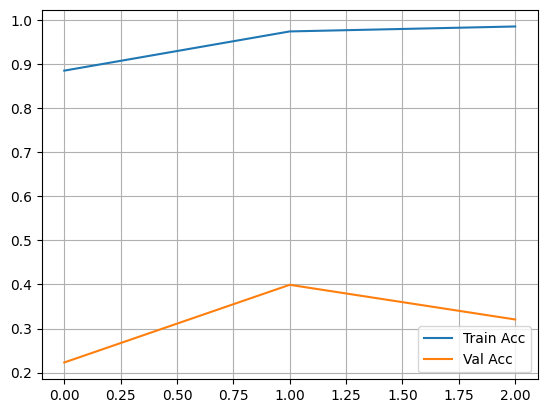

✅ Model saved as geo_cnn_optimized.h5


In [33]:
import os
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers, callbacks, mixed_precision
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt

# ✅ Mixed precision for faster training
mixed_precision.set_global_policy("mixed_float16")

# ✅ Paths
base_dir = r"/Users/ashutosh/ProjectMajor/TESTTRAINVALSPLIT"
train_dir = os.path.join(base_dir, "train")
val_dir   = os.path.join(base_dir, "val")
test_dir  = os.path.join(base_dir, "test")

# ✅ Image & Batch Settings
img_size = (128, 128)
batch_size = 64

# ✅ Data Augmentation
train_aug = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)
val_test_aug = ImageDataGenerator(rescale=1./255)

# ✅ Data Generators
train_data = train_aug.flow_from_directory(train_dir, target_size=img_size, batch_size=batch_size, class_mode="categorical")
val_data   = val_test_aug.flow_from_directory(val_dir, target_size=img_size, batch_size=batch_size, class_mode="categorical")
test_data  = val_test_aug.flow_from_directory(test_dir, target_size=img_size, batch_size=batch_size, class_mode="categorical")

num_classes = len(train_data.class_indices)

# ✅ SE Block
def se_block(input_tensor, reduction=16):
    channels = input_tensor.shape[-1]
    se = layers.GlobalAveragePooling2D()(input_tensor)
    se = layers.Dense(channels // reduction, activation="relu")(se)
    se = layers.Dense(channels, activation="sigmoid")(se)
    se = layers.Reshape((1,1,channels))(se)
    return layers.multiply([input_tensor, se])

# ✅ Depthwise Separable Convolution Block
def conv_block(x, filters, strides=1):
    res = x
    x = layers.SeparableConv2D(filters, 3, padding="same", strides=strides, use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    x = se_block(x)
    if res.shape[-1] != filters:
        res = layers.Conv2D(filters, 1, strides=strides, padding="same")(res)
    x = layers.add([x, res])
    x = layers.Activation("relu")(x)
    return x

# ✅ GeoCNN Model Definition
def create_geo_cnn(input_shape, num_classes):
    inputs = layers.Input(shape=input_shape)
    x = layers.Conv2D(32, 3, padding="same", activation="relu")(inputs)
    x = layers.BatchNormalization()(x)

    # Blocks
    x = conv_block(x, 64)
    x = layers.MaxPooling2D(2)(x)
    x = conv_block(x, 128)
    x = layers.MaxPooling2D(2)(x)
    x = conv_block(x, 256)
    x = layers.GlobalAveragePooling2D()(x)

    # Final Classifier
    x = layers.Dropout(0.4)(x)
    outputs = layers.Dense(num_classes, activation="softmax", dtype="float32")(x)

    model = models.Model(inputs, outputs)
    return model

# ✅ Compile Model
geo_cnn = create_geo_cnn(input_shape=(128, 128, 3), num_classes=num_classes)
geo_cnn.compile(optimizer=optimizers.Adam(learning_rate=0.001),
                loss="categorical_crossentropy",
                metrics=["accuracy"])

geo_cnn.summary()

# ✅ Callbacks
early_stop = callbacks.EarlyStopping(patience=5, restore_best_weights=True)
reduce_lr  = callbacks.ReduceLROnPlateau(patience=3, factor=0.5, min_lr=1e-6, verbose=1)

# ✅ Train
history = geo_cnn.fit(
    train_data,
    validation_data=val_data,
    epochs=3,
    callbacks=[early_stop, reduce_lr]
)

# ✅ Evaluate
test_loss, test_acc = geo_cnn.evaluate(test_data)
print(f"Test Accuracy: {test_acc:.4f}")

# ✅ Plot Learning Curves
plt.plot(history.history["accuracy"], label="Train Acc")
plt.plot(history.history["val_accuracy"], label="Val Acc")
plt.legend()
plt.grid()
plt.show()

# ✅ Save Model
geo_cnn.save("geo_cnn_optimized.h5")
print("✅ Model saved as geo_cnn_optimized.h5")
